In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned_telco_churn.csv")

In [3]:
df.shape

(7032, 21)

In [7]:
df['TotalCharges'].isnull().sum()

0

CHURN DISTRIBUTION
Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


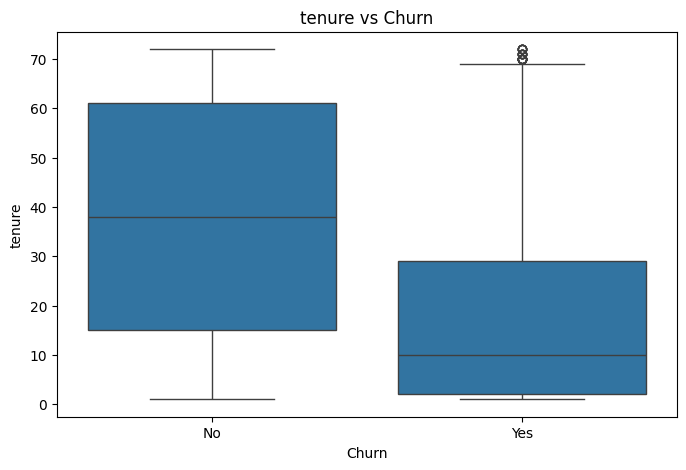

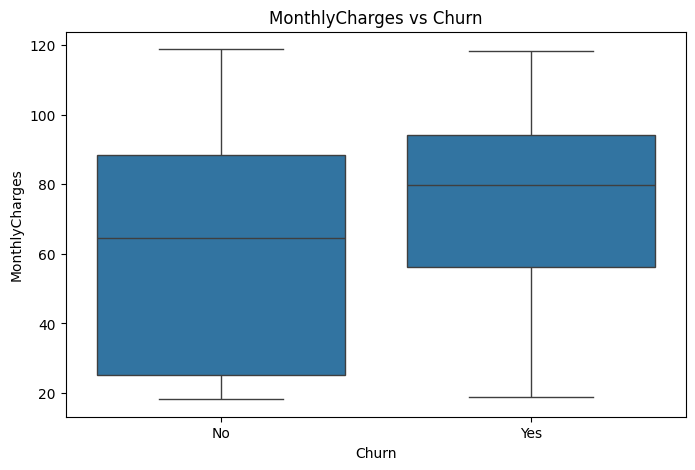

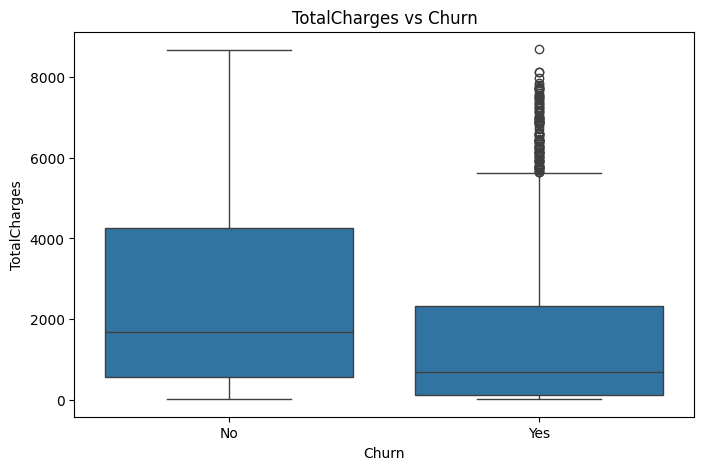

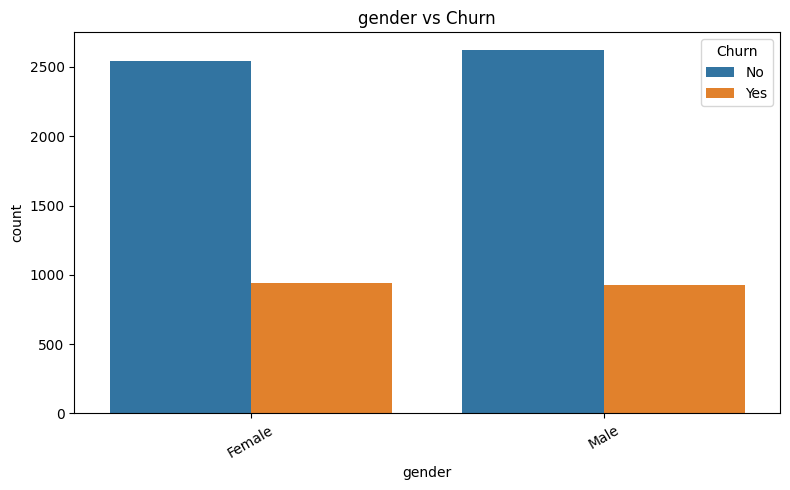

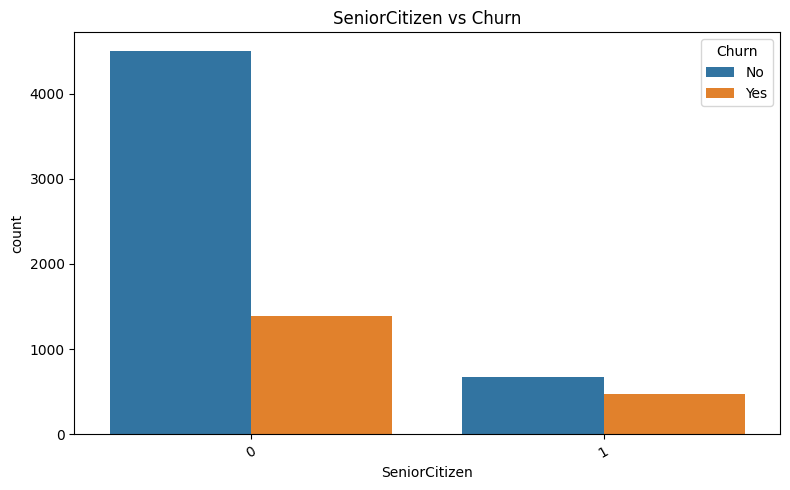

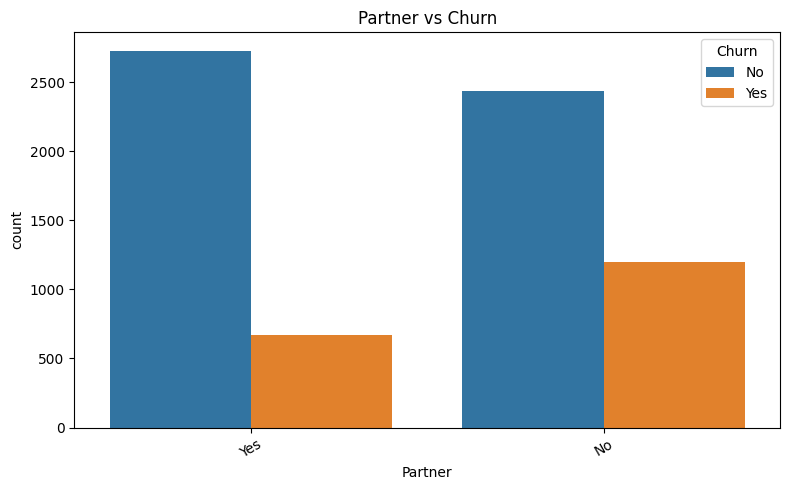

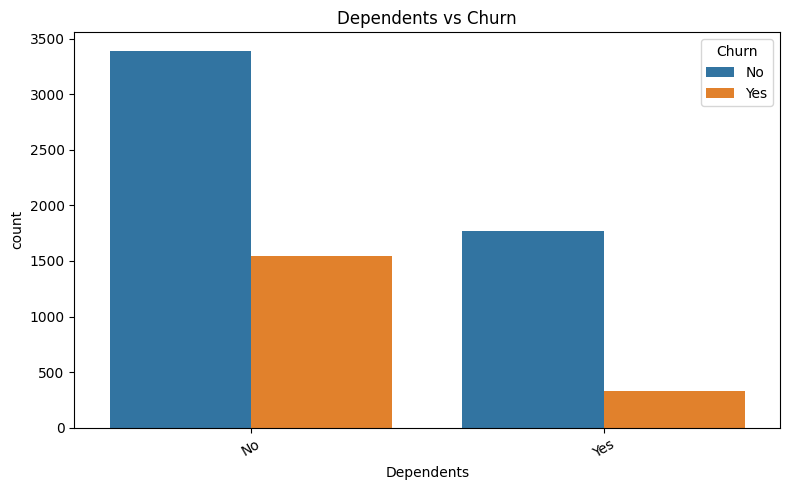

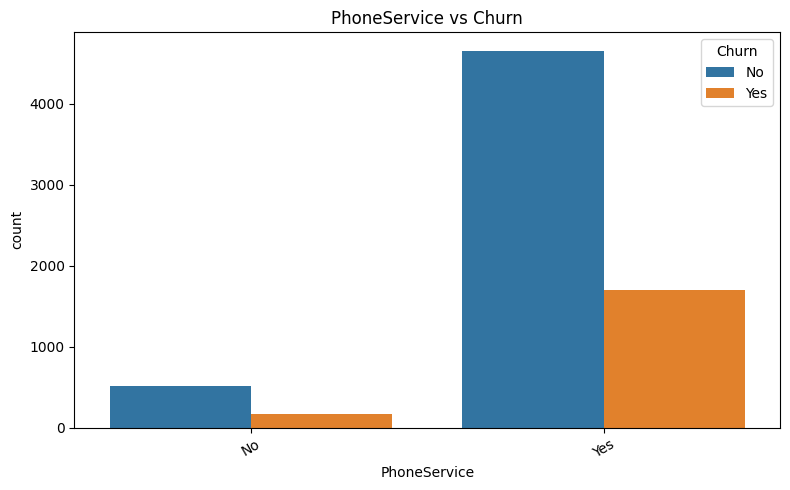

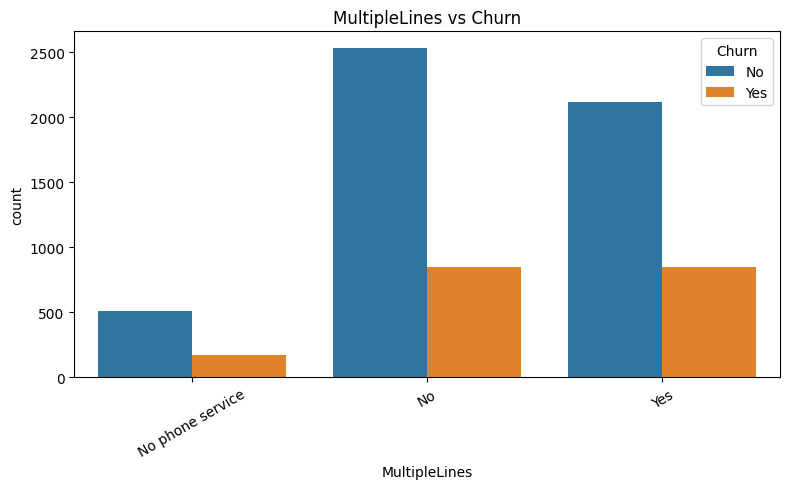

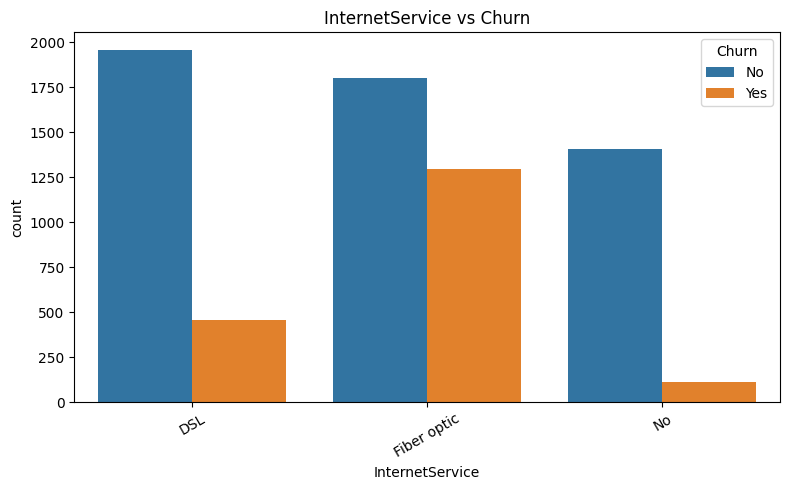

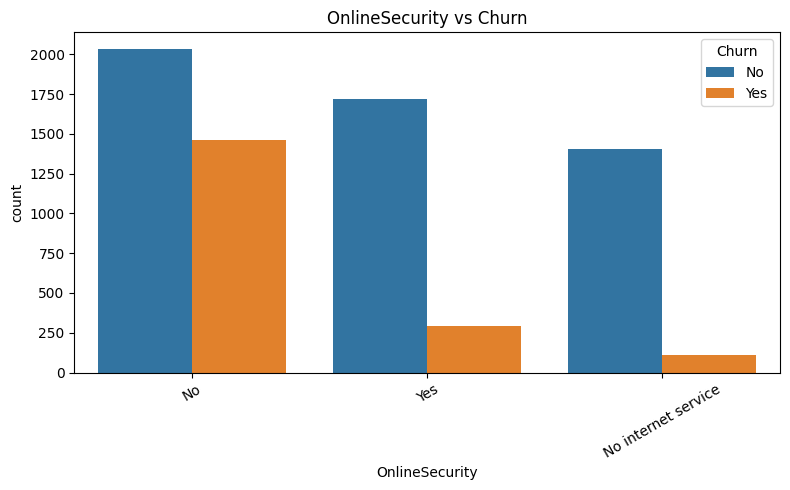

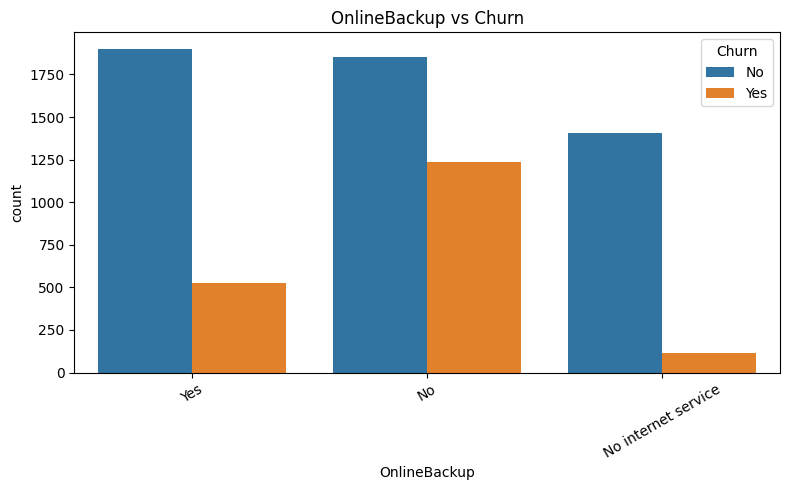

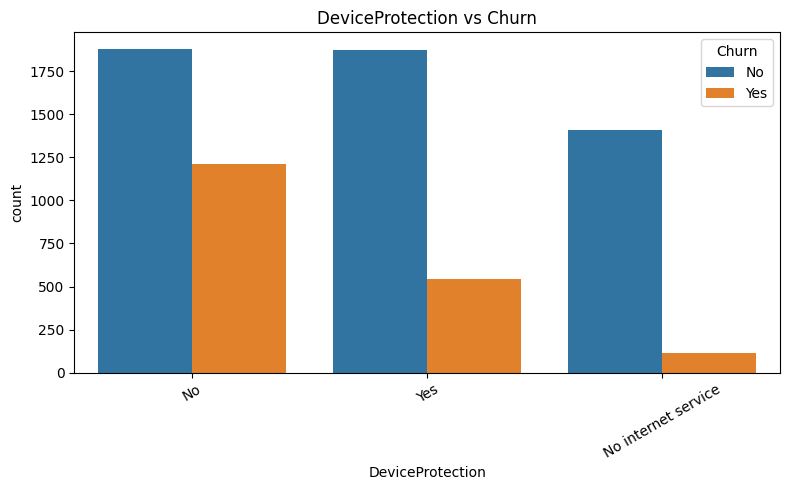

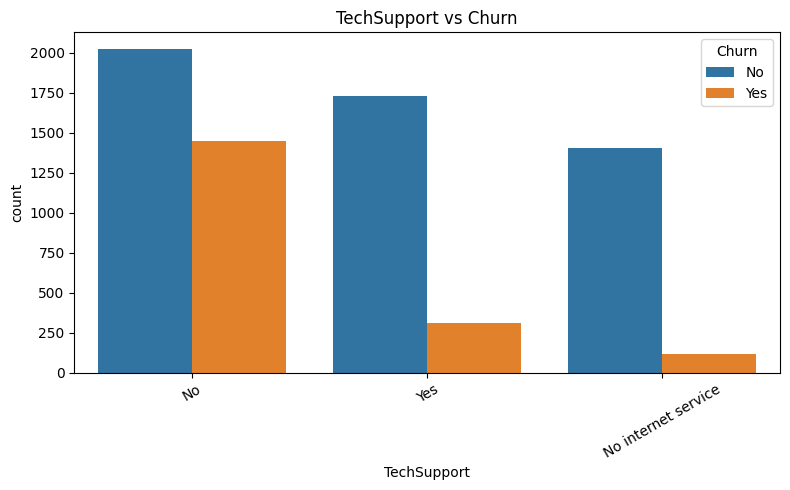

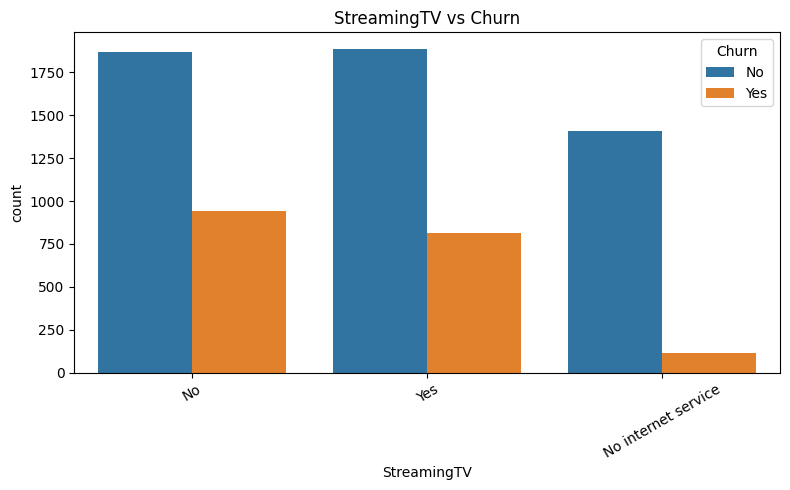

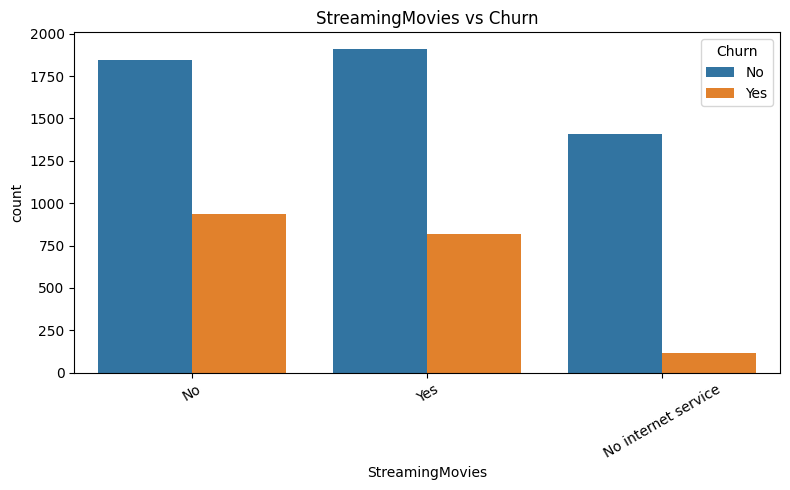

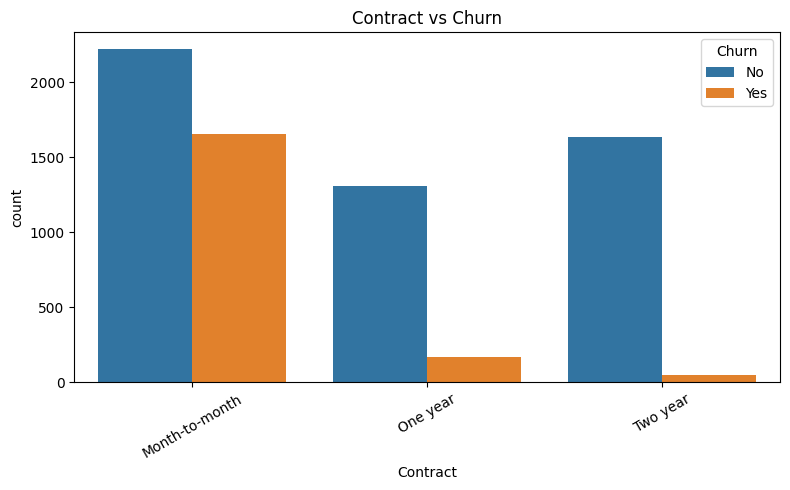

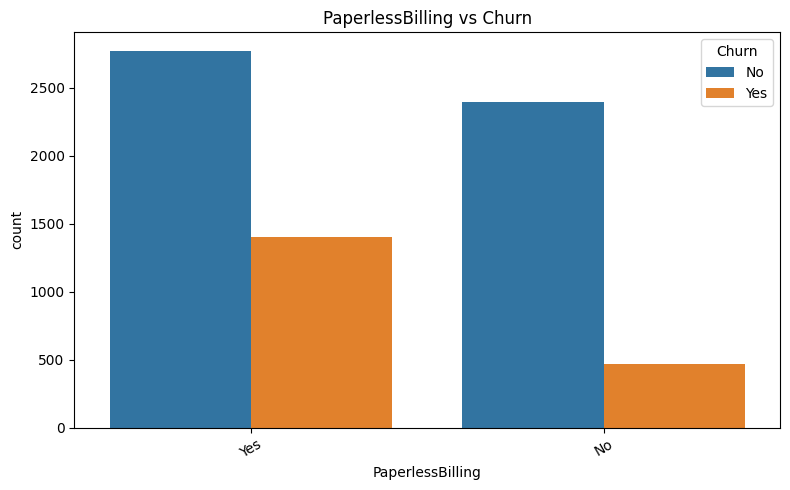

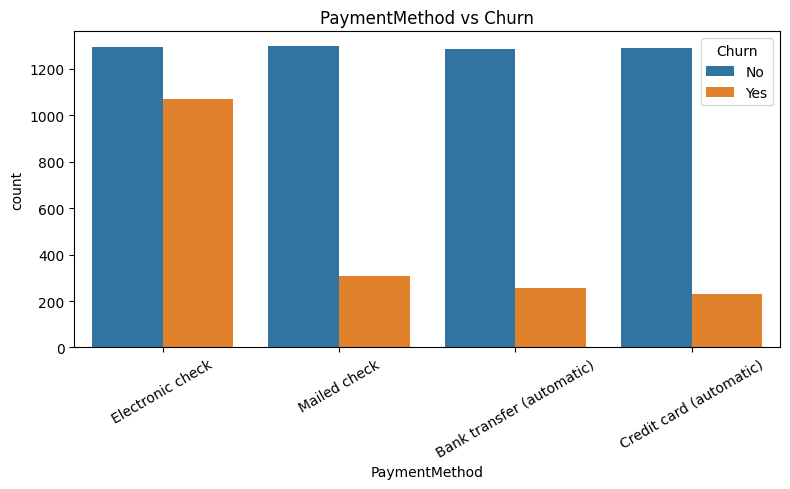


CHURN RATES BY CATEGORY


--- gender ---
Churn      No    Yes
gender              
Female  73.04  26.96
Male    73.80  26.20

--- SeniorCitizen ---
Churn             No    Yes
SeniorCitizen              
0              76.35  23.65
1              58.32  41.68

--- Partner ---
Churn       No    Yes
Partner              
No       67.02  32.98
Yes      80.28  19.72

--- Dependents ---
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.47  15.53

--- PhoneService ---
Churn            No    Yes
PhoneService              
No            75.00  25.00
Yes           73.25  26.75

--- MultipleLines ---
Churn                No    Yes
MultipleLines                 
No                74.92  25.08
No phone service  75.00  25.00
Yes               71.35  28.65

--- InternetService ---
Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43

--- OnlineSecurity ---
Churn  

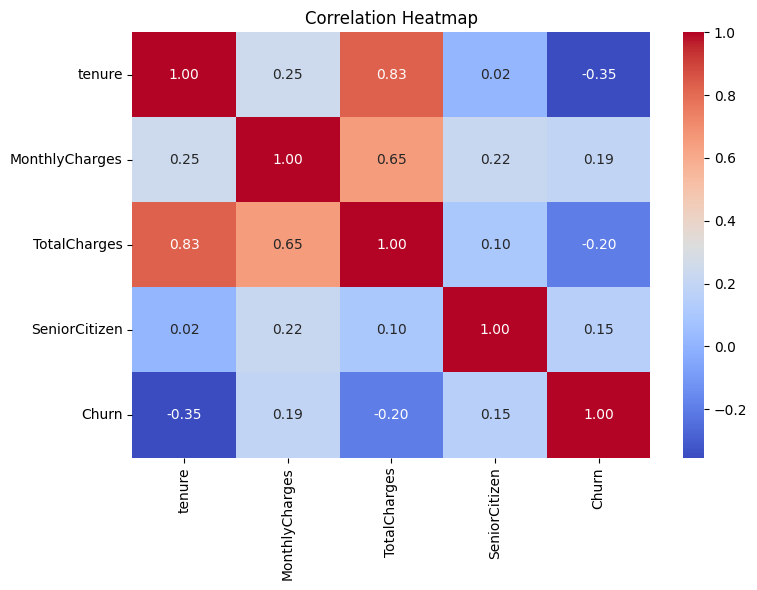

In [8]:
# =========================
# COMPLETE EDA
# =========================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------
# 1. Churn Distribution
# -------------------------
print("CHURN DISTRIBUTION")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)


# -------------------------
# 2. Numerical Features
# -------------------------
numerical_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for col in numerical_cols:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Churn",
        y=col
    )

    plt.title(f"{col} vs Churn")
    plt.show()


# -------------------------
# 3. Categorical Features
# -------------------------
categorical_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for col in categorical_cols:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=col,
        hue="Churn"
    )

    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


# -------------------------
# 4. Churn Rate by Category
# -------------------------
print("\nCHURN RATES BY CATEGORY\n")

for col in categorical_cols:

    churn_rate = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    ) * 100

    print(f"\n--- {col} ---")
    print(churn_rate.round(2))


# -------------------------
# 5. Numerical Summary
# -------------------------
print("\nNUMERICAL FEATURES BY CHURN")

print(
    df.groupby("Churn")[numerical_cols]
      .agg(["mean", "median", "min", "max"])
      .round(2)
)


# -------------------------
# 6. Correlation
# -------------------------
numeric_df = df[numerical_cols + ["SeniorCitizen"]].copy()

numeric_df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [9]:
# Churn rate for every categorical feature

for col in categorical_cols:
    churn_rate = (
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    print(f"\n{col}")
    print(churn_rate.round(2))


gender
gender
Female    26.96
Male      26.20
Name: Churn, dtype: float64

SeniorCitizen
SeniorCitizen
1    41.68
0    23.65
Name: Churn, dtype: float64

Partner
Partner
No     32.98
Yes    19.72
Name: Churn, dtype: float64

Dependents
Dependents
No     31.28
Yes    15.53
Name: Churn, dtype: float64

PhoneService
PhoneService
Yes    26.75
No     25.00
Name: Churn, dtype: float64

MultipleLines
MultipleLines
Yes                 28.65
No                  25.08
No phone service    25.00
Name: Churn, dtype: float64

InternetService
InternetService
Fiber optic    41.89
DSL            19.00
No              7.43
Name: Churn, dtype: float64

OnlineSecurity
OnlineSecurity
No                     41.78
Yes                    14.64
No internet service     7.43
Name: Churn, dtype: float64

OnlineBackup
OnlineBackup
No                     39.94
Yes                    21.57
No internet service     7.43
Name: Churn, dtype: float64

DeviceProtection
DeviceProtection
No                     39.14
Yes   

In [10]:
eda_summary = []

for col in categorical_cols:
    rates = (
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )

    eda_summary.append({
        "Feature": col,
        "Highest Churn Category": rates.idxmax(),
        "Highest Churn Rate": rates.max(),
        "Lowest Churn Category": rates.idxmin(),
        "Lowest Churn Rate": rates.min(),
        "Gap": rates.max() - rates.min()
    })

eda_summary = pd.DataFrame(eda_summary)

eda_summary = eda_summary.sort_values(
    "Gap",
    ascending=False
)

eda_summary.round(2)

,Feature,Highest Churn Category,Highest Churn Rate,Lowest Churn Category,Lowest Churn Rate,Gap
13,Contract,Month-to-month,42.71,Two year,2.85,39.86
6,InternetService,Fiber optic,41.89,No,7.43,34.46
7,OnlineSecurity,No,41.78,No internet service,7.43,34.34
10,TechSupport,No,41.65,No internet service,7.43,34.21
8,OnlineBackup,No,39.94,No internet service,7.43,32.51
9,DeviceProtection,No,39.14,No internet service,7.43,31.71
15,PaymentMethod,Electronic check,45.29,Credit card (automatic),15.25,30.03
12,StreamingMovies,No,33.73,No internet service,7.43,26.29
11,StreamingTV,No,33.54,No internet service,7.43,26.10
1,SeniorCitizen,1,41.68,0,23.65,18.03


In [11]:
numerical_summary = (
    df.groupby("Churn")[numerical_cols]
      .mean()
      .T
)

numerical_summary["Difference"] = (
    numerical_summary["Yes"] -
    numerical_summary["No"]
)

numerical_summary.round(2)

Churn,No,Yes,Difference
tenure,37.65,17.98,-19.67
MonthlyCharges,61.31,74.44,13.13
TotalCharges,2555.34,1531.80,-1023.55


In [12]:
eda_summary.to_csv(
    "../data/eda_categorical_summary.csv",
    index=False
)

numerical_summary.to_csv(
    "../data/eda_numerical_summary.csv"
)